# Splits com prevenção de vazamento

Antes de ajustar qualquer modelo sobre as UDVs é preciso decidir quais audiências ele pode ver e quais
ficam reservadas para medir se ele generaliza. Este notebook constrói o primeiro desses recortes, o
split temporal: treino no passado, teste no futuro. O caminho é o mesmo em todas as seções: mostrar o
problema, medir o dado real e só então fixar a regra. O dataset não traz campo de data, então a maior
parte do trabalho está em extrair a data do texto livre da matéria e em verificar se ela pode ser usada
como base de ordenação.

In [1]:
import json
from collections import Counter

import pandas as pd

In [2]:
with open("dataset/PublicHearingBR_LDS.jsonl") as f:
    lds_records = [json.loads(line) for line in f]

records_by_id = {record["id"]: record for record in lds_records}
print(f"audiências: {len(lds_records)}")

audiências: 206


## O problema: por que um sorteio aleatório não serve

Sortear opiniões ao acaso para treino e teste vazaria de duas formas. A primeira é estrutural: as
opiniões de uma mesma audiência compartilham a transcrição, os participantes e o assunto, então a mesma
audiência apareceria dos dois lados e o modelo seria avaliado sobre um texto que já viu. A segunda é
temporal: pautas duram semanas no Congresso, e um recorte aleatório deixaria o modelo aprender o
vocabulário de um debate que ainda estava em curso no período de teste. A unidade de divisão, portanto,
é a audiência, não a opinião, e a ordem é a cronológica.

In [3]:
opinions_per_hearing = {
    record["id"]: sum(len(person["opinioes"]) for person in record["metadados"]["envolvidos"])
    for record in lds_records
}
print(f"opiniões: {sum(opinions_per_hearing.values())}")
print(
    f"por audiência: mínimo {min(opinions_per_hearing.values())}, "
    f"máximo {max(opinions_per_hearing.values())}, "
    f"mediana {sorted(opinions_per_hearing.values())[len(opinions_per_hearing) // 2]}"
)

opiniões: 2203
por audiência: mínimo 3, máximo 31, mediana 10


## Onde a data está

O schema real do LDS não tem campo de data, comissão nem URL: cada registro é `id`, `materia`,
`transcricao` e `metadados`. O que existe é o carimbo de publicação da matéria da Agência Câmara, em
texto corrido, logo abaixo do título e da linha fina.

In [4]:
print(sorted(lds_records[0].keys()))
print(sorted(lds_records[0]["metadados"].keys()))

['id', 'materia', 'metadados', 'transcricao']
['assunto', 'envolvidos']


In [5]:
print(lds_records[0]["materia"][:260])

Jornalistas acusam Alexandre de Moraes de censura ao exigir bloqueio de contas da rede social X
Deputados governistas criticam falta do contraditório em debate e defendem regras para as redes sociais


16/04/2024 - 19:07  


Jornalistas ouvidos nesta terça-fei


O carimbo tem formato fixo, `DD/MM/AAAA - HH:MM`, e é capturado por

```
(\d{2})/(\d{2})/(\d{4})\s*-\s*(\d{2}):(\d{2})
```

com uma ressalva: algumas matérias foram atualizadas depois de publicadas e trazem um segundo carimbo
precedido de `Atualizado em`. A extração ignora qualquer carimbo que caia dentro de

```
Atualizado\s+em\s+(\d{2})/(\d{2})/(\d{4})\s*-\s*(\d{2}):(\d{2})
```

e devolve o primeiro que sobra, que é o de publicação.

In [6]:
from utils.hearing_dates import TIMESTAMP_PATTERN, article_date, published_at, updated_at

article_dates = {record["id"]: article_date(record["materia"]) for record in lds_records}
located = sum(1 for value in article_dates.values() if value is not None)
print(f"com carimbo de publicação: {located} de {len(lds_records)}")

com carimbo de publicação: 206 de 206


In [7]:
stamps_per_article = Counter(len(TIMESTAMP_PATTERN.findall(record["materia"])) for record in lds_records)
updated_ids = [record["id"] for record in lds_records if updated_at(record["materia"])]
print("carimbos por matéria:", dict(sorted(stamps_per_article.items())))
print(f"matérias com 'Atualizado em': {len(updated_ids)}")

carimbos por matéria: {1: 193, 2: 13}
matérias com 'Atualizado em': 13


In [8]:
updated_sample = records_by_id[updated_ids[0]]
print(updated_sample["materia"][:300])
print("publicação:", published_at(updated_sample["materia"]))
print("atualização:", updated_at(updated_sample["materia"]))

Ministro do Trabalho volta a defender alternativa ao saque-aniversário no FGTS
Deputado que pediu o debate com o ministro criticou a proposta: “O saque-aniversário é como se fosse o 14º salário do trabalhador”


17/04/2024 - 15:26  
•   Atualizado em 17/04/2024 - 19:08


O ministro do Trabalho e Emp
publicação: 2024-04-17 15:26:00
atualização: 2024-04-17 19:08:00


Todas as 206 matérias têm carimbo, e as 13 que têm dois carimbos são exatamente as que foram
atualizadas: o segundo carimbo nunca aparece antes do primeiro, então tomar o primeiro que não está sob
`Atualizado em` é suficiente.

## A data extraída é a data da audiência?

O carimbo é a hora em que a matéria foi publicada, não um campo da audiência. Usá-lo para ordenar só se
sustenta se a publicação acompanhar o evento. O texto das matérias permite checar isso sem nenhuma
fonte externa: elas costumam nomear o dia do debate na forma `nesta quarta-feira (17)`. O dia do mês
citado é reconstruído como a data mais recente até o carimbo que tenha aquele dia, e então se compara o
dia da semana citado com o dia da semana dessa data. Só as menções com `nesta`/`neste` entram, porque
as demais podem se referir a eventos futuros ou passados mencionados de passagem.

In [9]:
from utils.hearing_dates import check_article_date

date_checks = {record["id"]: check_article_date(record["materia"]) for record in lds_records}
current_mentions = [
    (hearing_id, mention)
    for hearing_id, check in date_checks.items()
    for mention in check["mentions"]
    if mention["names_current_event"]
]
agreeing = [pair for pair in current_mentions if pair[1]["weekday_agrees"]]
print(f"menções ao dia do evento: {len(current_mentions)}, concordam: {len(agreeing)}")
print(
    "defasagem publicação menos evento, em dias:",
    dict(sorted(Counter(mention["lag_days"] for _, mention in agreeing).items())),
)

menções ao dia do evento: 159, concordam: 157
defasagem publicação menos evento, em dias: {0: 142, 1: 15}


In [10]:
mentioning_hearings = {hearing_id for hearing_id, _ in current_mentions}
confirmed_hearings = {hearing_id for hearing_id, _ in agreeing}
print(f"audiências que nomeiam o dia: {len(mentioning_hearings)}")
print(f"confirmadas por ao menos uma menção: {len(confirmed_hearings)}")
print("sem nenhuma menção concordante:", sorted(mentioning_hearings - confirmed_hearings))

audiências que nomeiam o dia: 156
confirmadas por ao menos uma menção: 155
sem nenhuma menção concordante: [111]


In [11]:
for hearing_id, mention in current_mentions:
    if not mention["weekday_agrees"]:
        print(hearing_id, date_checks[hearing_id]["article_date"], mention["text"], mention["resolved_date"])

111 2024-03-26 nesta terça-feira (23) 2024-03-23
116 2023-12-13 nesta quinta-feira (14) 2023-11-14


Das 156 audiências cujas matérias nomeiam o dia do debate, 155 confirmam a data extraída. As duas
menções que divergem têm causas diferentes: na audiência 116 a matéria cita um segundo evento, no dia
seguinte, além do que ela relata; na 111 o número do dia citado, 23, caiu num sábado, enquanto o dia da
semana citado, terça-feira, é o do próprio carimbo, o que é erro da matéria.

A defasagem entre a publicação e o evento é de zero dia em 142 menções e de um dia em 15, e nunca
maior. A data do carimbo é, então, a data da audiência com erro de no máximo um dia, sempre para
frente. Isso basta para ordenar, desde que nenhuma fronteira de split caia dentro dessa margem, o que
é verificado adiante.

## Distribuição temporal

As 206 audiências não estão distribuídas de forma uniforme entre novembro de 2021 e maio de 2024: a
maior parte é de 2023, há meses inteiros sem nenhuma, e há um vazio entre o fim de dezembro e o começo
de março que corresponde ao recesso parlamentar.

In [12]:
monthly = Counter(day.strftime("%Y-%m") for day in article_dates.values())
monthly_table = pd.DataFrame(sorted(monthly.items()), columns=["mês", "audiências"])
monthly_table["acumulado"] = monthly_table["audiências"].cumsum()
monthly_table["fração"] = (monthly_table["acumulado"] / len(lds_records)).round(3)
monthly_table

,mês,audiências,acumulado,fração
0,2021-11,3,3,0.015
1,2022-03,1,4,0.019
2,2022-04,1,5,0.024
3,2022-05,4,9,0.044
4,2022-06,8,17,0.083
5,2022-07,7,24,0.117
6,2022-08,5,29,0.141
7,2022-09,1,30,0.146
8,2022-11,4,34,0.165
9,2022-12,1,35,0.170


In [13]:
print("por ano:", dict(sorted(Counter(day.year for day in article_dates.values()).items())))
print(f"datas distintas: {len(set(article_dates.values()))}")
print(f"máximo de audiências num mesmo dia: {max(Counter(article_dates.values()).values())}")

por ano: {2021: 3, 2022: 32, 2023: 141, 2024: 30}
datas distintas: 128
máximo de audiências num mesmo dia: 5


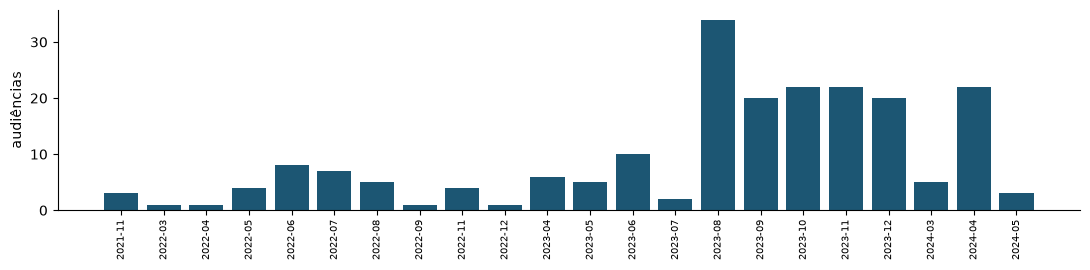

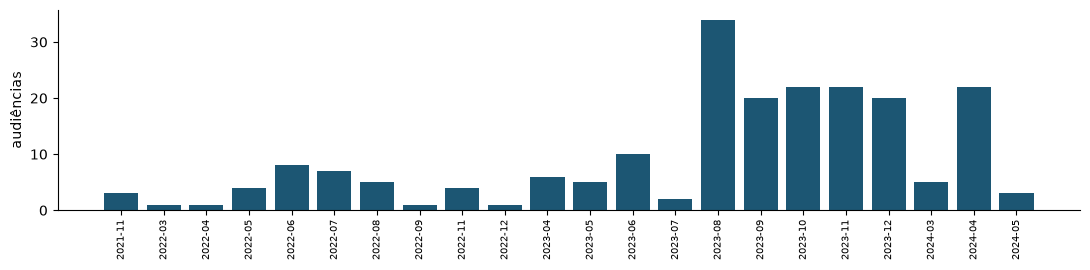

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

figure, axes = plt.subplots(figsize=(11, 2.8))
axes.bar(monthly_table["mês"], monthly_table["audiências"], color="#1C5673")
axes.set_xticks(range(len(monthly_table)))
axes.set_xticklabels(monthly_table["mês"], rotation=90, fontsize=7)
axes.set_ylabel("audiências")
axes.spines[["top", "right"]].set_visible(False)
figure.tight_layout()
figure

## Escolha dos cortes

Com 128 datas distintas e até 5 audiências no mesmo dia, o corte precisa cair entre datas, nunca dentro
de uma: duas audiências do mesmo dia têm que ficar do mesmo lado. Além disso, como a data tem erro de
até um dia, um corte entre dois dias consecutivos poderia trocar uma audiência de lado. A regra
adotada é, portanto: considerar como corte apenas as datas cujo intervalo até a próxima data com
audiência é de ao menos 2 dias, e entre elas escolher a que deixa a fração acumulada mais perto do
alvo, desempatando pelo maior intervalo.

In [15]:
from utils.build_splits import choose_boundary, cut_candidates

candidates = cut_candidates(article_dates, 2)
candidates_table = pd.DataFrame(candidates)
print(f"cortes possíveis com intervalo de ao menos 2 dias: {len(candidates)}")
candidates_table[candidates_table["fraction"].between(0.62, 0.90)]

cortes possíveis com intervalo de ao menos 2 dias: 65


,date,next_date,gap_days,cumulative,fraction
47,2023-10-26,2023-10-30,4,131,0.635922
48,2023-10-31,2023-11-07,7,134,0.650485
49,2023-11-09,2023-11-13,4,143,0.694175
50,2023-11-13,2023-11-21,8,144,0.699029
51,2023-11-22,2023-11-24,2,147,0.713592
52,2023-11-24,2023-11-28,4,148,0.718447
53,2023-11-30,2023-12-05,5,156,0.757282
54,2023-12-07,2023-12-11,4,163,0.791262
55,2023-12-14,2023-12-19,5,172,0.834951
56,2023-12-20,2024-03-05,76,176,0.854369


In [16]:
train_cut = choose_boundary(candidates, 0.70, None)
validation_cut = choose_boundary(candidates, 0.85, train_cut["date"])
print("fim do treino:", train_cut)
print("fim da validação:", validation_cut)

fim do treino: {'date': datetime.date(2023, 11, 13), 'next_date': datetime.date(2023, 11, 21), 'gap_days': 8, 'cumulative': 144, 'fraction': 0.6990291262135923}
fim da validação: {'date': datetime.date(2023, 12, 20), 'next_date': datetime.date(2024, 3, 5), 'gap_days': 76, 'cumulative': 176, 'fraction': 0.8543689320388349}


Os dois cortes escolhidos caem em lacunas do calendário legislativo. O primeiro, em 13/11/2023, acumula
69,9% das audiências e tem 8 dias até a próxima; o segundo, em 20/12/2023, acumula 85,4% e tem 76 dias
até a próxima, que é o recesso. Ambos os intervalos são muito maiores que o erro de um dia da data
extraída, então nenhuma audiência poderia mudar de lado por causa dessa imprecisão.

## O split

Com os cortes fixados, cada audiência vai para o conjunto correspondente e cada UDV acompanha a
audiência de onde saiu.

In [17]:
from utils.build_splits import SPLIT_NAMES, assign_splits

groups = assign_splits(article_dates, train_cut["date"], validation_cut["date"])
split_of = {hearing_id: name for name in SPLIT_NAMES for hearing_id in groups[name]}
pd.DataFrame(
    [
        {
            "split": name,
            "audiências": len(groups[name]),
            "fração": round(len(groups[name]) / len(lds_records), 3),
            "primeira": min(article_dates[i] for i in groups[name]),
            "última": max(article_dates[i] for i in groups[name]),
            "opiniões": sum(opinions_per_hearing[i] for i in groups[name]),
        }
        for name in SPLIT_NAMES
    ]
)

,split,audiências,fração,primeira,última,opiniões
0,train,144,0.699,2021-11-18,2023-11-13,1536
1,validation,32,0.155,2023-11-21,2023-12-20,308
2,test,30,0.146,2024-03-05,2024-05-09,359


In [18]:
with open("artifacts/udv/udv_v0.jsonl") as f:
    udv_records = [json.loads(line) for line in f]

tier_table = pd.crosstab(
    pd.Series([split_of[udv["hearing_id"]] for udv in udv_records], name="split"),
    pd.Series([udv["tier"] for udv in udv_records], name="tier"),
)
tier_table.loc[list(SPLIT_NAMES)]

tier,no_evidence,person_not_resolved,quote_found,semantic_match_high,semantic_match_weak
split,,,,,
train,2,80,171,1246,37
validation,0,3,49,249,7
test,6,7,40,298,8


A distribuição de níveis não é igual entre os conjuntos. As opiniões de pessoa não resolvida se
concentram no treino: são 80 das 90, ou 5,2% do treino contra 1,0% da validação e 1,9% do teste, porque
os formatos de cabeçalho que o resolvedor erra são os das audiências mais antigas. As 8 opiniões sem
evidência também ficam desbalanceadas, 6 delas no teste. Ao comparar métricas entre conjuntos, parte da
diferença virá dessa composição, não do modelo.

## O que o split temporal não isola

Separar por tempo resolve o vazamento de pauta em curso, não os outros. Duas coisas continuam
atravessando a fronteira e precisam ficar registradas.

In [19]:
from pathlib import Path

from utils.build_splits import actor_overlap, cross_split_similarity, load_config

split_config = load_config(Path("configs/splits.toml"))
print(actor_overlap(groups, records_by_id))

{'distinct_actors': 879, 'in_more_than_one_split': 55, 'in_train_and_test': 24}


In [20]:
near_duplicates = cross_split_similarity(groups, records_by_id, split_config)
print({key: value for key, value in near_duplicates.items() if key != "top_pairs"})
pd.DataFrame(near_duplicates["top_pairs"]).head()

{'method': 'tfidf cosine over materia, min_df=2, sublinear_tf', 'threshold': 0.5, 'cross_split_pairs': 9888, 'above_threshold': 0, 'max': 0.459, 'p99': 0.185, 'median': 0.099}


,similarity,hearings,splits
0,0.459,"[68, 105]","[train, test]"
1,0.397,"[15, 129]","[train, validation]"
2,0.334,"[94, 5]","[train, test]"
3,0.331,"[194, 19]","[train, validation]"
4,0.308,"[123, 114]","[validation, test]"


In [21]:
closest = near_duplicates["top_pairs"][0]
for hearing_id in closest["hearings"]:
    print(hearing_id, split_of[hearing_id], records_by_id[hearing_id]["metadados"]["assunto"])

68 train Falhas no protocolo do SUS para o tratamento da retinopatia diabética
105 test Atualização do protocolo de tratamento de edema macular diabético no SUS


A primeira é o ator: 55 dos 879 nomes distintos aparecem em mais de um conjunto e 24 aparecem em treino
e teste. Um ministro que depõe várias vezes no período é o caso típico. Isso é esperado num split
temporal e não é corrigível sem abrir mão da cronologia; quem quiser medir generalização para atores
inéditos precisa de um split por ator, que é outro recorte.

A segunda é a proximidade temática. A maior similaridade TF-IDF entre matérias de conjuntos diferentes
é 0,459, e nenhum par cruzando fronteira passa de 0,5, o corte registrado em `configs/splits.toml`.
Não há, portanto, audiência quase duplicada separada pelo split. O par mais próximo trata do mesmo tema
em momentos diferentes, que é justamente o que um split temporal deve permitir.

## Verificação

O manifesto é recomputado a partir do LDS por `utils/verify_splits.py`, que refaz a extração de data, a
escolha dos cortes e a atribuição, e confere a partição, a cronologia, o fato de nenhuma data cair em
dois conjuntos e os contadores do relatório. As mesmas funções são chamadas aqui.

In [22]:
from utils.verify_splits import (
    check_boundaries,
    check_chronology,
    check_dates,
    check_manifest_shape,
    check_partition,
)

with open("artifacts/splits/temporal_v1.json") as f:
    manifest = json.load(f)

problems = (
    check_manifest_shape(manifest)
    + check_partition(manifest, article_dates)
    + check_dates(manifest, article_dates)
    + check_chronology(manifest, article_dates, split_config.min_boundary_gap_days)
    + check_boundaries(manifest, article_dates, split_config)
)
print(f"problemas: {len(problems)}")

problemas: 0


O manifesto fica em `artifacts/splits/temporal_v1.json`, no formato com `split_version`,
`grouping_method`, `seed` e as três listas de `id`, mais as datas extraídas de cada audiência para que
a atribuição possa ser refeita sem executar nada. O relatório com todos os números acima fica em
`artifacts/splits/temporal_v1_report.json`. Ambos são regerados por

```
uv run python -m utils.build_splits
uv run python -m utils.verify_splits
```

O split temporal é determinístico e não consome a semente; ela é gravada no manifesto porque os splits
por similaridade e por comissão, ainda não construídos, vão precisar dela.